# <center>__Project Title - Hybrid Movie Recommendation System with FastAPI, Streamlit & Docker__</center>

## Problem Statement :

In today’s digital world, users are overwhelmed with a vast number of choices on streaming platforms. Finding relevant content becomes difficult due to the large volume of available movies.

Traditional search methods fail to provide personalized suggestions based on user preferences and behavior.

The objective of this project is to build a scalable and intelligent recommendation system that:

analyzes user behavior (ratings)

understands movie features (genres, metadata)

provides personalized movie recommendations

using a combination of collaborative filtering and content-based filtering techniques.

## Project Summary :

This project focuses on building an end-to-end hybrid movie recommendation system using the MovieLens dataset. The system leverages both user interaction data and movie metadata to generate accurate and personalized recommendations.

The solution integrates multiple machine learning techniques:

1) Collaborative Filtering to recommend movies based on similar user preferences

2) Content-Based Filtering to suggest movies with similar attributes

3) A Hybrid Approach to combine both methods for improved performance

To simulate a real-world production system, the model is deployed using:

*    FastAPI for backend API development

*    Streamlit for an interactive user interface

*    Docker for containerization and easy deployment

The application allows users to:

*    search for movies

*    get personalized recommendations

*    explore similar movies

*    view top-rated and trending content

This project demonstrates the complete machine learning lifecycle, including:

*    data preprocessing and EDA

*    model development and evaluation

*    API development

*    UI integration
    
*    deployment-ready architecture

## GitHub Link :

**https://github.com/chetansgode/Hybrid_Movie_Recommendation_System_Project**

## Import Libraries :

In [1]:
#data pre-processing
import pandas as pd 
import numpy as np 
#data visualisation
import matplotlib.pyplot as plt 
import seaborn as sns
#to show max columns
pd.set_option('display.max_columns', None)


## Loading Dataset :

In [2]:
#Loading data
df_movies=pd.read_csv("datasets/movies.dat",sep='::',encoding='latin-1',engine='python',names=['movieId', 'title', 'genres'])

df_ratings = pd.read_csv("datasets/ratings.dat", sep="::", engine='python',names=['userId', 'movieId', 'rating', 'timestamp'])

df_users=pd.read_csv("datasets/users.dat",sep="::",engine='python',names=['userId','gender','age','occupation','zip'])

## Variables Description:

The dataset used in this project is the MovieLens 1M dataset, which contains user ratings, movie details, and user demographic information.

1) **Movies Dataset (movies.dat)**

Variable	Description

movieId	: Unique identifier for each movie

title	: Name of the movie along with release year

genres	: List of genres associated with the movie (separated by |)

2) **Ratings Dataset (ratings.dat)**

Variable	Description

userId : Unique identifier for each user

movieId :	Unique identifier for each movie

rating	: Rating given by the user to the movie (scale: 1–5)

timestamp :	Time at which the rating was provided (Unix format)

3) **Users Dataset (users.dat)**

Variable	Description

userId :	Unique identifier for each user

gender :	Gender of the user (M/F)

age :	Age group of the user (encoded values)

    *  1:  "Under 18"
	* 18:  "18-24"
	* 25:  "25-34"
	* 35:  "35-44"
	* 45:  "45-49"
	* 50:  "50-55"
	* 56:  "56+"

occupation :	Occupation of the user (coded values)

    *  0:  "other" or not specified
	*  1:  "academic/educator"
	*  2:  "artist"
	*  3:  "clerical/admin"
	*  4:  "college/grad student"
	*  5:  "customer service"
	*  6:  "doctor/health care"
	*  7:  "executive/managerial"
	*  8:  "farmer"
	*  9:  "homemaker"
	* 10:  "K-12 student"
	* 11:  "lawyer"
	* 12:  "programmer"
	* 13:  "retired"
	* 14:  "sales/marketing"
	* 15:  "scientist"
	* 16:  "self-employed"
	* 17:  "technician/engineer"
	* 18:  "tradesman/craftsman"
	* 19:  "unemployed"
	* 20:  "writer"

zip :	Zip code of the user

## Dataset First View :

#### Shape:

In [3]:
names=["df_movies","df_ratings","df_users"]
for no,i in enumerate([df_movies,df_ratings,df_users]): 
    print(f"{names[no]} dataset has {i.shape[0]} rows and {i.shape[1]} columns")

df_movies dataset has 3883 rows and 3 columns
df_ratings dataset has 1000209 rows and 4 columns
df_users dataset has 6040 rows and 5 columns


#### Dataset Duplicate check :

In [4]:
for no,i in enumerate([df_movies,df_ratings,df_users]): 
    print(f"{names[no]} dataset has total null values : {i.duplicated().sum()}")

df_movies dataset has total null values : 0
df_ratings dataset has total null values : 0
df_users dataset has total null values : 0


#### Checking Null values in datasets :

In [5]:
for no,i in enumerate([df_movies,df_ratings,df_users]): 
    print(f"{names[no]} dataset has total null values :\n{i.isna().sum()}\n")

df_movies dataset has total null values :
movieId    0
title      0
genres     0
dtype: int64

df_ratings dataset has total null values :
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

df_users dataset has total null values :
userId        0
gender        0
age           0
occupation    0
zip           0
dtype: int64



#### Checking data types :

In [6]:

for no, i in enumerate([df_movies, df_ratings, df_users]): 
    print(f"\n{names[no]} dataset has data types :\n")
    i.info()
    print("-"*50)


df_movies dataset has data types :

<class 'pandas.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  3883 non-null   int64
 1   title    3883 non-null   str  
 2   genres   3883 non-null   str  
dtypes: int64(1), str(2)
memory usage: 91.1 KB
--------------------------------------------------

df_ratings dataset has data types :

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1000209 non-null  int64
 1   movieId    1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB
--------------------------------------------------

df_users dataset has data types :

<class 'pandas.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 

In [7]:
df_movies.head(2)

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy


In [8]:
df_ratings.head(2)

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109


In [9]:
df_users.head(2)

,userId,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072


#### Data Cleaning :

In [10]:
#changing data type of df_ratings dataset timestamp columns (int) to (date)
df_ratings['timestamp']=pd.to_datetime(df_ratings['timestamp'], unit='s')


## Merging Data sets:

In [11]:
df=pd.merge(df_movies,df_ratings,on='movieId')
df=pd.merge(df,df_users,on='userId')

In [12]:
df.head()

,movieId,title,genres,userId,rating,timestamp,gender,age,occupation,zip
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,2001-01-06 23:37:48,F,1,10,48067
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,2000-12-31 04:30:08,F,50,9,55117
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,2000-12-31 03:31:36,M,25,12,11413
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,2000-12-31 01:25:52,M,25,17,61614
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,2000-12-31 01:34:34,F,35,1,95370


## Feature Engineering :

In [13]:
#extract year from title 
df['year']=df['title'].apply(lambda x: x[-5:-1])
# extract movie_name from title 
df['movie_name']=df['title'].apply(lambda x: x[:-6])
#create hour features
df['hour']=df['timestamp'].dt.hour

## EDA

#### 1) Analyzing the top 100 and bottom 100 rated movies :

In [14]:
#checking top 100 rated movies
top_rated_movies=df.groupby('title')['rating'].mean().reset_index().sort_values('rating',ascending=False).head(100)
#checking bottom 100 rated movies
bottom_rated_movies=df.groupby('title')['rating'].mean().reset_index().sort_values('rating',ascending=True).head(100)
print('Top rated 20 movies :\n')
print(top_rated_movies.head(20))
print('-'*50)
print('Bottom rated 20 movies :\n')
print(bottom_rated_movies.head(20))
print('-'*50)

Top rated 20 movies :

                                                  title    rating
2025                                       Lured (1947)  5.000000
3477                            Ulysses (Ulisse) (1954)  5.000000
249                                    Baby, The (1973)  5.000000
1203                            Follow the Bitch (1998)  5.000000
2903          Schlafes Bruder (Brother of Sleep) (1995)  5.000000
407                            Bittersweet Motel (2000)  5.000000
3087                             Song of Freedom (1936)  5.000000
1297                 Gate of Heavenly Peace, The (1995)  5.000000
2453                           One Little Indian (1973)  5.000000
3044                               Smashing Time (1967)  5.000000
1622                I Am Cuba (Soy Cuba/Ya Kuba) (1964)  4.800000
1870                                    Lamerica (1994)  4.750000
199                             Apple, The (Sib) (1998)  4.666667
2883                                     Sanjuro (196

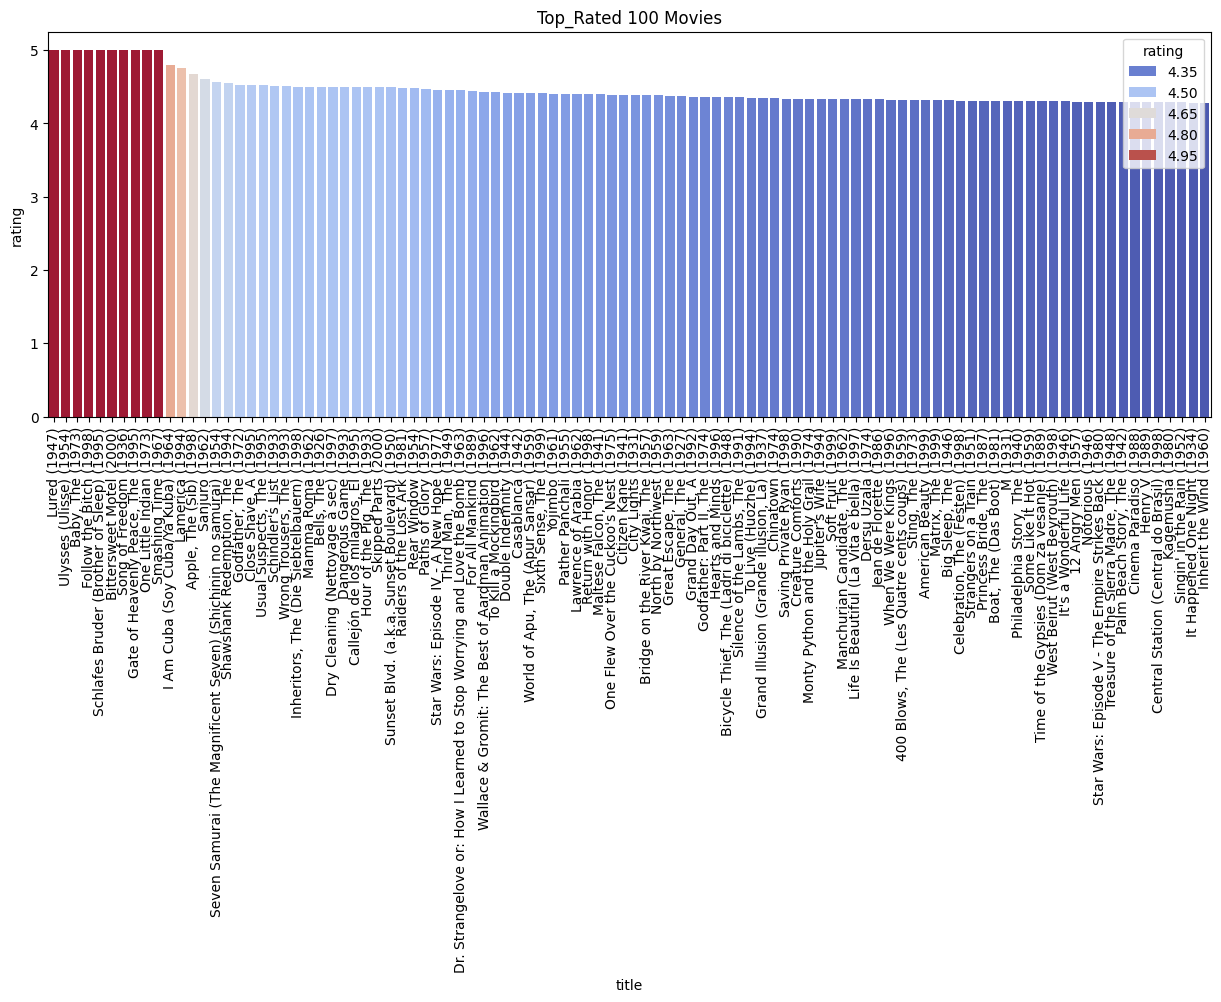

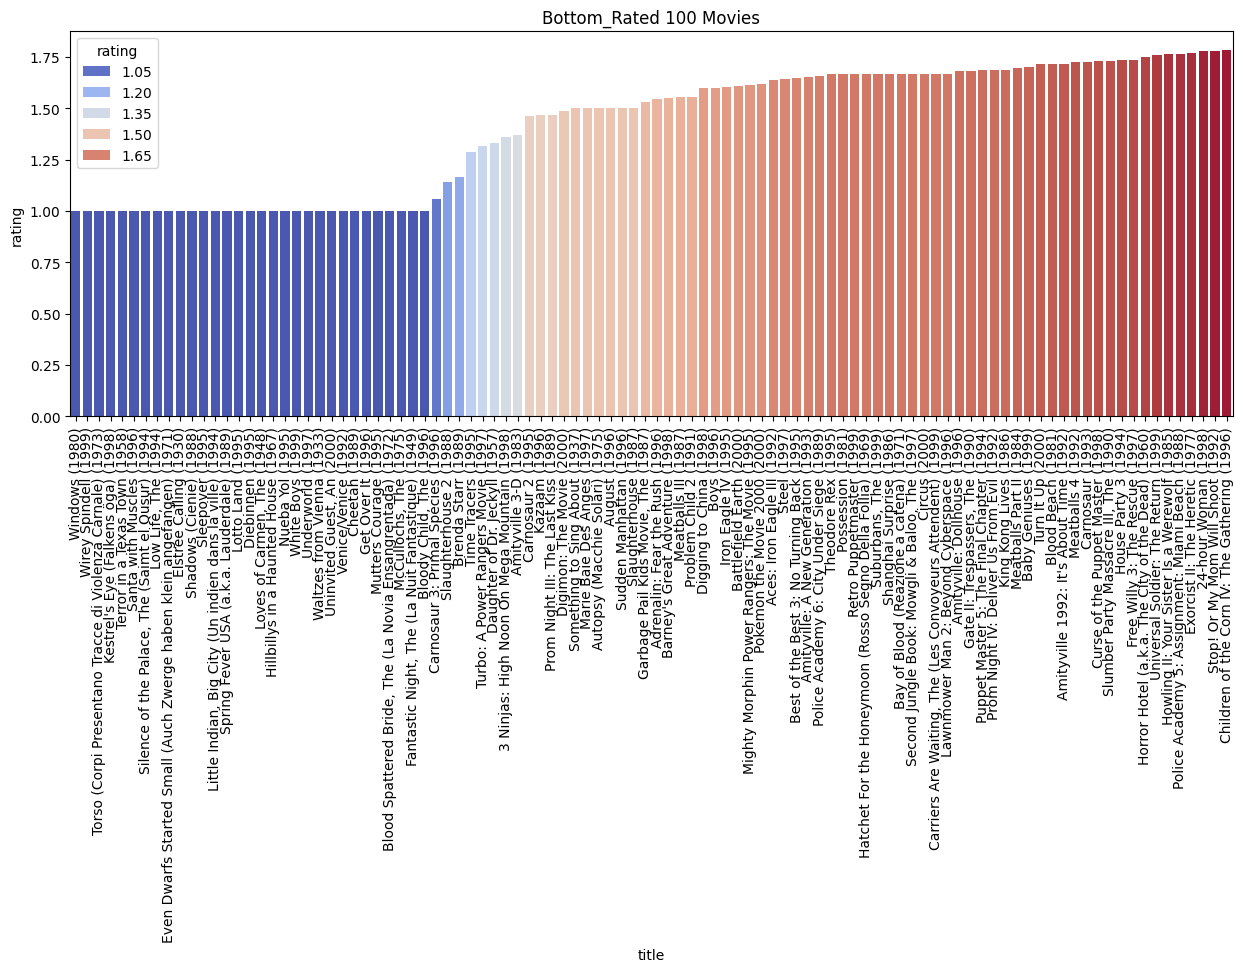

In [15]:
#for top rated movies
plt.figure(figsize=(15,5))
sns.barplot(top_rated_movies,x='title',y='rating',hue='rating',palette='coolwarm')
plt.title('Top_Rated 100 Movies')
plt.xticks(rotation=90) 
plt.show()

# for bottom rated movies 
plt.figure(figsize=(15,5))
sns.barplot(bottom_rated_movies,x='title',y='rating',hue='rating',palette='coolwarm')
plt.title('Bottom_Rated 100 Movies')
plt.xticks(rotation=90) 
plt.show()

##### Insights :

* above is the list of Top and Bottom rated movies

#### 2) How many movies were released year-wise? :

In [16]:
#checking no of movie release every year on year
movie_release_year_on_year=df.groupby(['year'])['movie_name'].nunique().reset_index().rename(columns={'movie_name':'movie_counts'})
movie_release_year_on_year

,year,movie_counts
0,1919,3
1,1920,1
2,1921,1
3,1922,1
4,1923,2
...,...,...
76,1996,312
77,1997,304
78,1998,317
79,1999,271


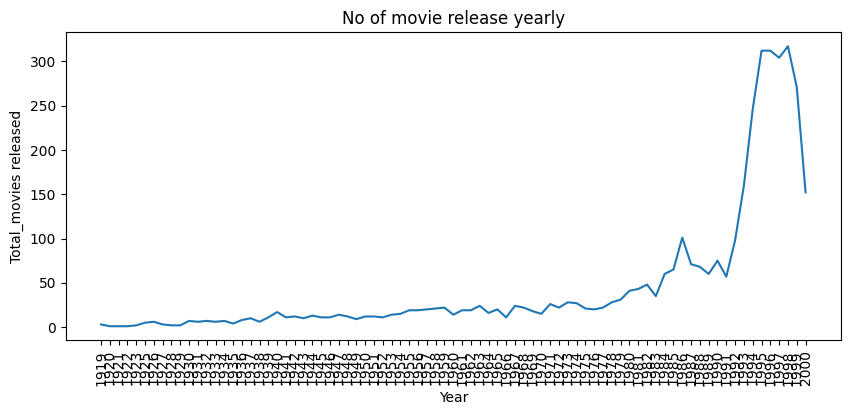

In [17]:
plt.figure(figsize=(10,4))
plt.plot(movie_release_year_on_year['year'],movie_release_year_on_year['movie_counts'])
plt.xticks(rotation=90)
plt.title('No of movie release yearly')
plt.xlabel('Year')
plt.ylabel('Total_movies released')
plt.show()

##### Insight:

* In year 1920,1921,1922 total movie release is 1 which is lowest in all time
* In year 1998 highest no of movie release is 317


In [18]:
df.head(2)

,movieId,title,genres,userId,rating,timestamp,gender,age,occupation,zip,year,movie_name,hour
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,2001-01-06 23:37:48,F,1,10,48067,1995,Toy Story,23
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,2000-12-31 04:30:08,F,50,9,55117,1995,Toy Story,4


#### 3)Who gives more ratings, males or females?
#### 4) When did people give the most ratings??

In [19]:
#genderwise rating
gender_rating = df.groupby('gender')['rating'].agg(['count', 'mean']).reset_index()

gender_rating

,gender,count,mean
0,F,246440,3.620366
1,M,753769,3.568879


In [20]:
#hourly rating
hourly_rating = df.groupby('hour')['rating'].agg(['count', 'mean']).reset_index()

hourly_rating

,hour,count,mean
0,0,55397,3.576746
1,1,58223,3.579874
2,2,59068,3.598615
3,3,62396,3.590390
4,4,55443,3.548762
5,5,42064,3.502829
6,6,33987,3.558184
7,7,27519,3.538864
8,8,20547,3.627634
9,9,12959,3.555521


Text(0.5, 0, 'timing in 24 hr')

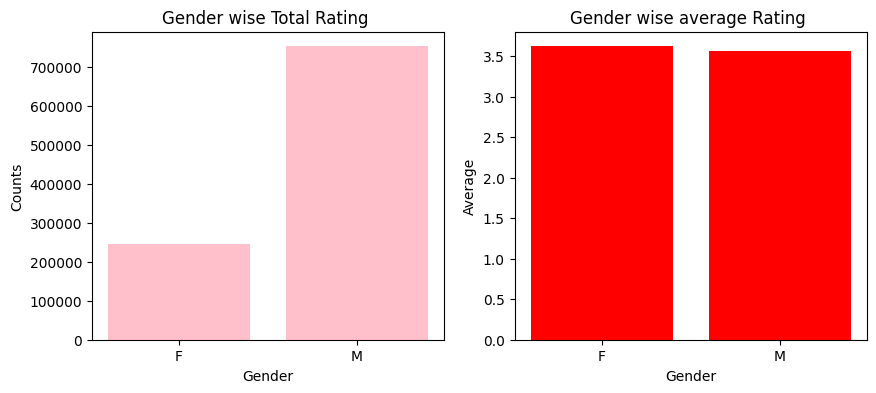

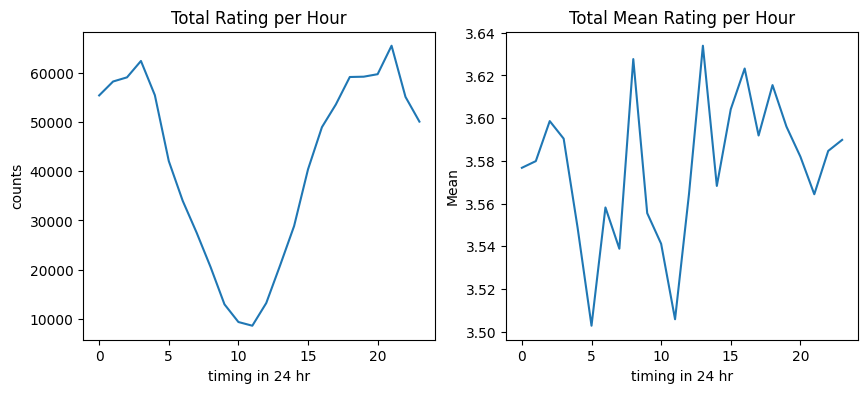

In [21]:
#ploting gender wise rating 
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(gender_rating['gender'],gender_rating['count'],color='pink')
plt.title('Gender wise Total Rating ')
plt.ylabel('Counts')
plt.xlabel('Gender')
plt.subplot(1,2,2)
plt.bar(gender_rating['gender'],gender_rating['mean'],color='red')
plt.title('Gender wise average Rating ')
plt.ylabel('Average')
plt.xlabel('Gender')


#create line plot to check no of rating with time
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hourly_rating['hour'],hourly_rating['count'])
plt.title('Total Rating per Hour')
plt.ylabel('counts')
plt.xlabel('timing in 24 hr')
plt.subplot(1,2,2)
plt.plot(hourly_rating['hour'],hourly_rating['mean'])
plt.title('Total Mean Rating per Hour')
plt.ylabel('Mean')
plt.xlabel('timing in 24 hr')


##### Insight :

* Male has given no of rating higher than Female
* Average rating of Female is higher than Male
* In between 9-11 am in morning there is lowest rating in whole day 

In [22]:
df.head()

,movieId,title,genres,userId,rating,timestamp,gender,age,occupation,zip,year,movie_name,hour
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,2001-01-06 23:37:48,F,1,10,48067,1995,Toy Story,23
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,2000-12-31 04:30:08,F,50,9,55117,1995,Toy Story,4
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,2000-12-31 03:31:36,M,25,12,11413,1995,Toy Story,3
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,2000-12-31 01:25:52,M,25,17,61614,1995,Toy Story,1
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,2000-12-31 01:34:34,F,35,1,95370,1995,Toy Story,1


#### 5) which age groups has given more rating and also count total counts ?

In [23]:
#total rating count age group wise
print('Age wise rating count :\n')
age_wise_rating=df.groupby('age')['rating'].count().reset_index().rename(columns={'rating':'total_counts'})
#actual age group show for better understanding
age_wise_rating['age']=pd.DataFrame(["Under 18","18-24","25-34","35-44","45-49", "50-55", "56+"])
print(age_wise_rating)

print('\nAge wise mean rating count :')
age_wise_mean_rating=df.groupby('age')['rating'].mean().reset_index().rename(columns={'rating':'mean_rating'})
#actual age group show for better understanding
age_wise_mean_rating['age']=pd.DataFrame(["Under 18","18-24","25-34","35-44","45-49", "50-55", "56+"])
age_wise_mean_rating

Age wise rating count :

        age  total_counts
0  Under 18         27211
1     18-24        183536
2     25-34        395556
3     35-44        199003
4     45-49         83633
5     50-55         72490
6       56+         38780

Age wise mean rating count :


,age,mean_rating
0,Under 18,3.549520
1,18-24,3.507573
2,25-34,3.545235
3,35-44,3.618162
4,45-49,3.638062
5,50-55,3.714512
6,56+,3.766632


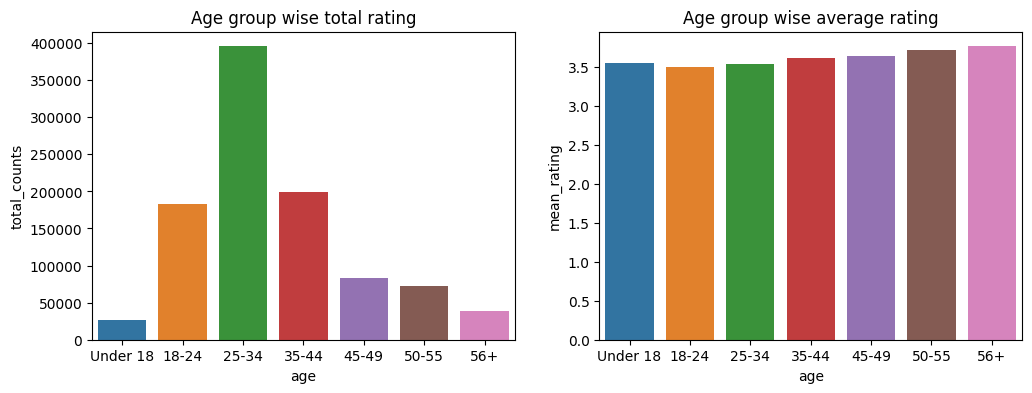

In [24]:
#age wise rating counts
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.barplot(age_wise_rating,x='age',y='total_counts',hue='age')
plt.title('Age group wise total rating')
plt.subplot(1,2,2)
sns.barplot(age_wise_mean_rating,x='age',y='mean_rating',hue='age')
plt.title('Age group wise average rating')
plt.show()

##### Insight :

* Age group "under 18" has given lowest rating count.
* Age group "25-34" has highest rating count.
* highest average rating in age group "56+"
* Lowestt average rating in age group "18-24"

#### 6) which occupation group has given more rating and also count total rating ?

In [25]:
#total rating count age group wise
print('Occupation wise rating count :\n')
occupation_wise_rating=df.groupby('occupation')['rating'].count().reset_index().rename(columns={'rating':'total_counts'})
#actual occupation group show for better understanding
occupation_wise_rating['occupation']=pd.DataFrame(["other or not specified",
"academic/educator", "artist","clerical/admin","college/grad student", "customer service","doctor/health care", "executive/managerial", "farmer", "homemaker",
 "K-12 student","lawyer","programmer", "retired",  "sales/marketing", "scientist", "self-employed", "technician/engineer", "tradesman/craftsman", "unemployed", "writer"])
print(occupation_wise_rating)

print('\nOccupation wise mean rating count :')
occupation_wise_mean_rating=df.groupby('occupation')['rating'].mean().reset_index().rename(columns={'rating':'mean_rating'})
#actual occupation group show for better understanding
occupation_wise_mean_rating['occupation']=pd.DataFrame(["other or not specified",
"academic/educator", "artist","clerical/admin","college/grad student", "customer service","doctor/health care", "executive/managerial", "farmer", "homemaker",
 "K-12 student","lawyer","programmer", "retired",  "sales/marketing", "scientist", "self-employed", "technician/engineer", "tradesman/craftsman", "unemployed", "writer"])
occupation_wise_mean_rating

Occupation wise rating count :

                occupation  total_counts
0   other or not specified        130499
1        academic/educator         85351
2                   artist         50068
3           clerical/admin         31623
4     college/grad student        131032
5         customer service         21850
6       doctor/health care         37205
7     executive/managerial        105425
8                   farmer          2706
9                homemaker         11345
10            K-12 student         23290
11                  lawyer         20563
12              programmer         57214
13                 retired         13754
14         sales/marketing         49109
15               scientist         22951
16           self-employed         46021
17     technician/engineer         72816
18     tradesman/craftsman         12086
19              unemployed         14904
20                  writer         60397

Occupation wise mean rating count :


,occupation,mean_rating
0,other or not specified,3.537544
1,academic/educator,3.576642
2,artist,3.573081
3,clerical/admin,3.656516
4,college/grad student,3.536793
5,customer service,3.537529
6,doctor/health care,3.661578
7,executive/managerial,3.599772
8,farmer,3.466741
9,homemaker,3.656589


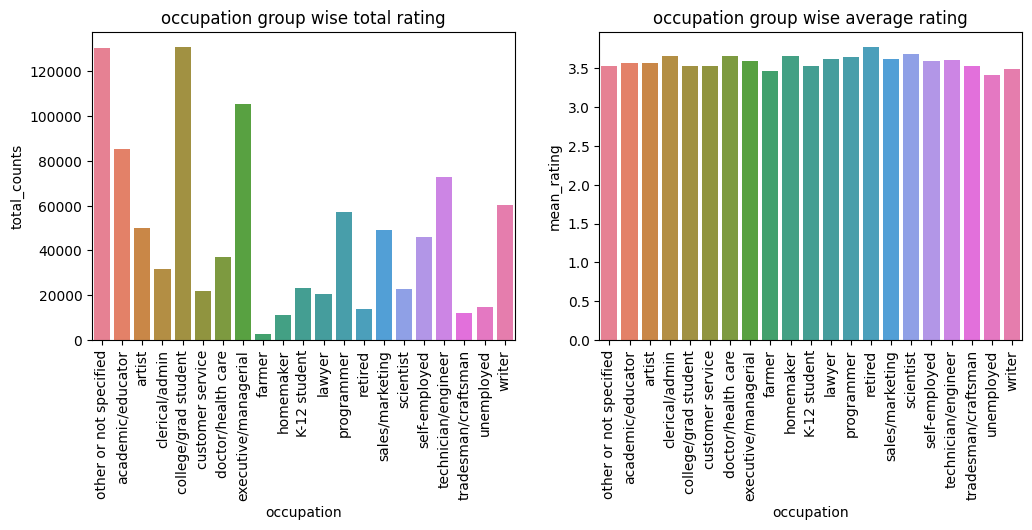

In [26]:
#age wise rating counts
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.barplot(occupation_wise_rating,x='occupation',y='total_counts',hue='occupation')
plt.title('occupation group wise total rating')
plt.xticks(rotation=90)
plt.subplot(1,2,2)
sns.barplot(occupation_wise_mean_rating,x='occupation',y='mean_rating',hue='occupation')
plt.title('occupation group wise average rating')
plt.xticks(rotation=90)
plt.show()

##### Insight :

* "college/grad student" has given highest rating counts.
* "farmer" has lowest rating counts.
* "unemployed" has given lower rating.
* "retired" has given higher rating.

#### 7) Analysis of genres wise rating 

In [27]:
#genres_wise_rating_count
print('Genres_wise_rating_count :\n')
genres_wise_rating_count=df.groupby('genres')['rating'].count().reset_index().rename(columns={'rating':'total_counts'}).sort_values('total_counts',ascending=False)
print(genres_wise_rating_count)
print('\nGenres_wise_mean_rating_count :')
genres_wise_mean_rating_count=df.groupby('genres')['rating'].mean().reset_index().rename(columns={'rating':'mean_rating'}).sort_values('mean_rating',ascending=False)
genres_wise_mean_rating_count

Genres_wise_rating_count :

                        genres  total_counts
176                     Comedy        116883
239                      Drama        111423
207             Comedy|Romance         42712
185               Comedy|Drama         42245
252              Drama|Romance         29170
..                         ...           ...
257      Drama|Romance|Western            29
170         Children's|Fantasy            27
195  Comedy|Film-Noir|Thriller             5
267           Film-Noir|Horror             2
264                    Fantasy             1

[301 rows x 2 columns]

Genres_wise_mean_rating_count :


,genres,mean_rating
155,Animation|Comedy|Thriller,4.473837
297,Sci-Fi|War,4.449890
143,Animation,4.394336
268,Film-Noir|Mystery,4.367424
141,Adventure|War,4.346107
...,...,...
7,Action|Adventure|Children's|Fantasy,2.090909
195,Comedy|Film-Noir|Thriller,2.000000
8,Action|Adventure|Children's|Sci-Fi,1.874286
41,Action|Children's,1.742373


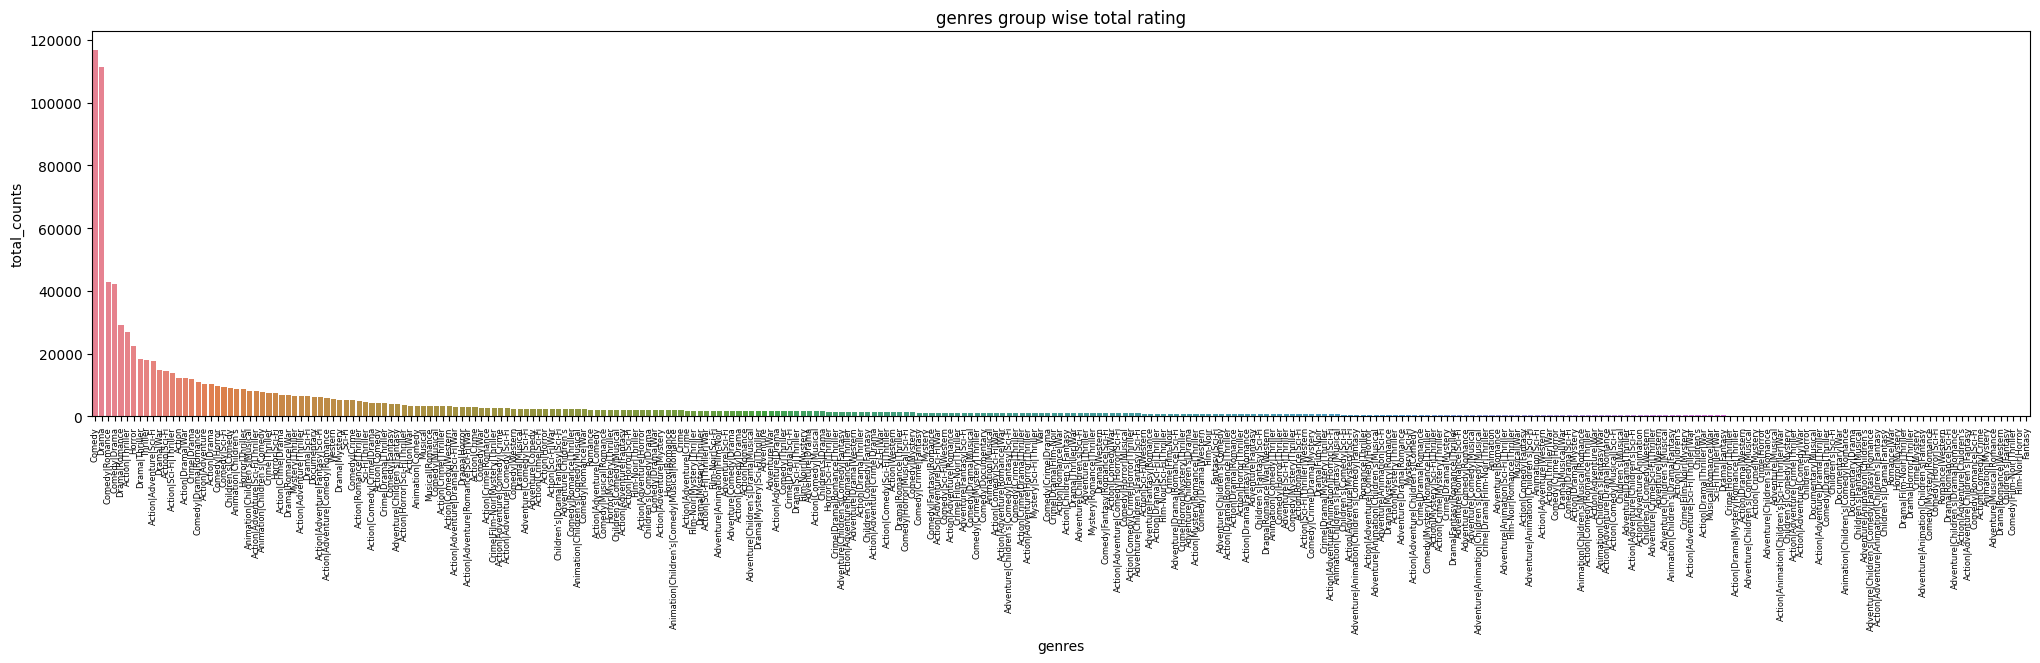

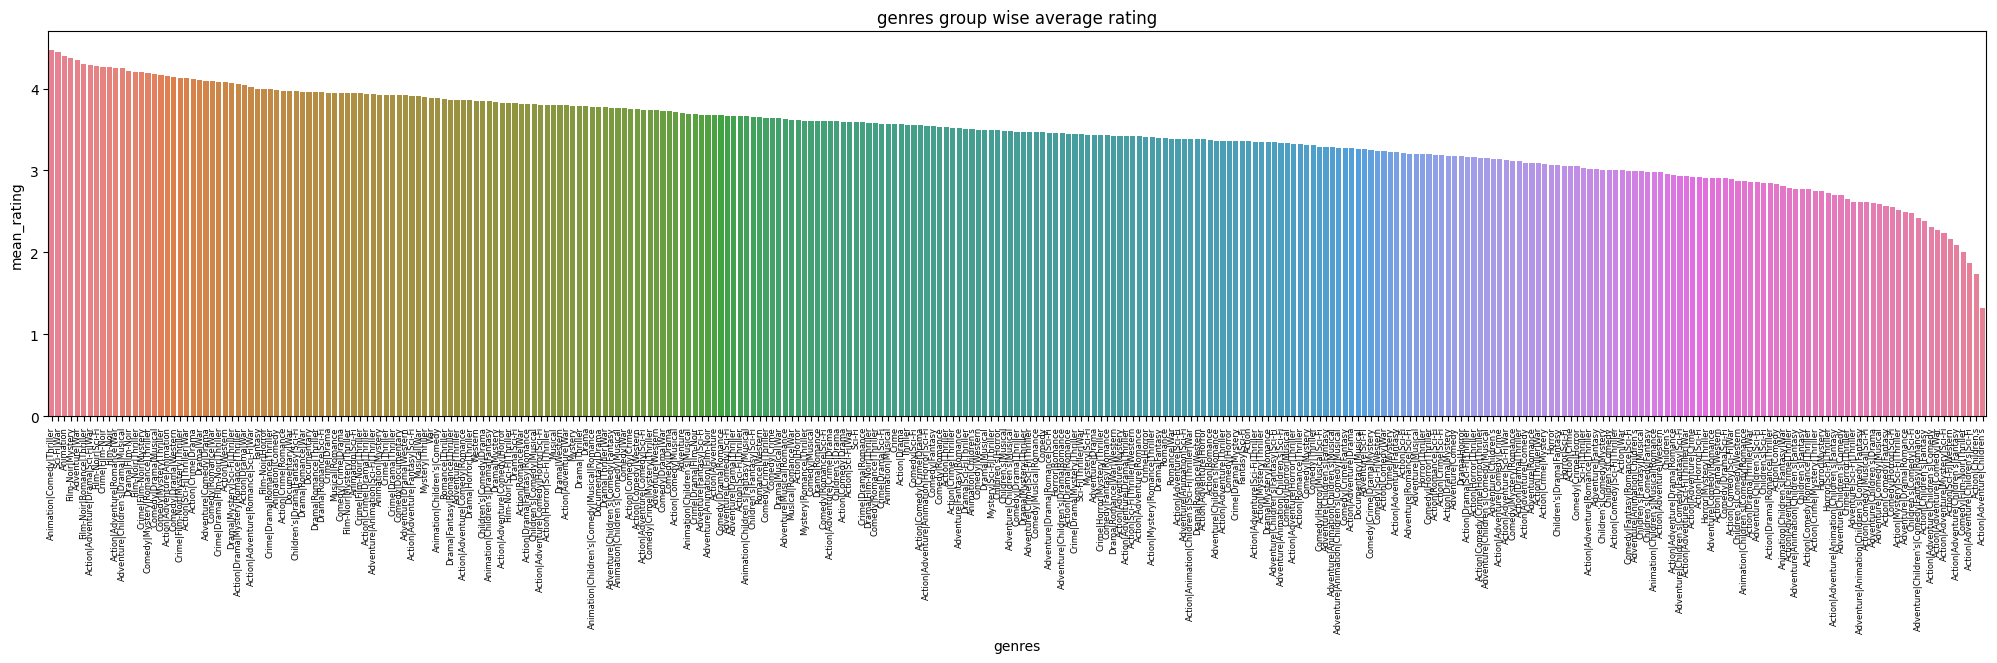

In [28]:
#age wise rating counts
plt.figure(figsize=(25,5))
sns.barplot(genres_wise_rating_count,x='genres',y='total_counts',hue='genres')
plt.title('genres group wise total rating')
plt.xticks(rotation=90,fontsize=6)
plt.show()

plt.figure(figsize=(25,5))
sns.barplot(genres_wise_mean_rating_count,x='genres',y='mean_rating',hue='genres')
plt.title('genres group wise average rating')
plt.xticks(rotation=90,fontsize=6)
plt.show()

##### Insight :

* Comedy genres has highest rating count
* Animation|Comedy|Thriller has highest mean rating 

#### 8) Analysis of Top and Bottom 10 rating zip wise :

In [37]:
top_rating_count_zip_wise=df.groupby('zip')['rating'].count().reset_index().rename(columns={'rating':'total_counts'}).sort_values('total_counts',ascending=False)
print('Top_rating_count_zip_wise :\n')
print(top_rating_count_zip_wise.head(10))
bottom_rating_count_zip_wise=df.groupby('zip')['rating'].count().reset_index().rename(columns={'rating':'total_counts'}).sort_values('total_counts',ascending=True)
print('\nBottom_rating_count_zip_wise :')
print(bottom_rating_count_zip_wise.head(10))

Top_rating_count_zip_wise :

        zip  total_counts
3057  94110          3802
2087  60640          3430
3352  98103          3204
3209  95616          3079
103   02138          3019
1903  55408          2787
1612  48135          2725
3312  97401          2663
418   10025          2632
417   10024          2594

Bottom_rating_count_zip_wise :
             zip  total_counts
3431       99508            20
3438       99945            20
17         01125            20
446        10583            20
1280       37042            20
451        10803            20
2410       77058            20
1270       36102            20
2438  77565-2332            20
1407       43612            20


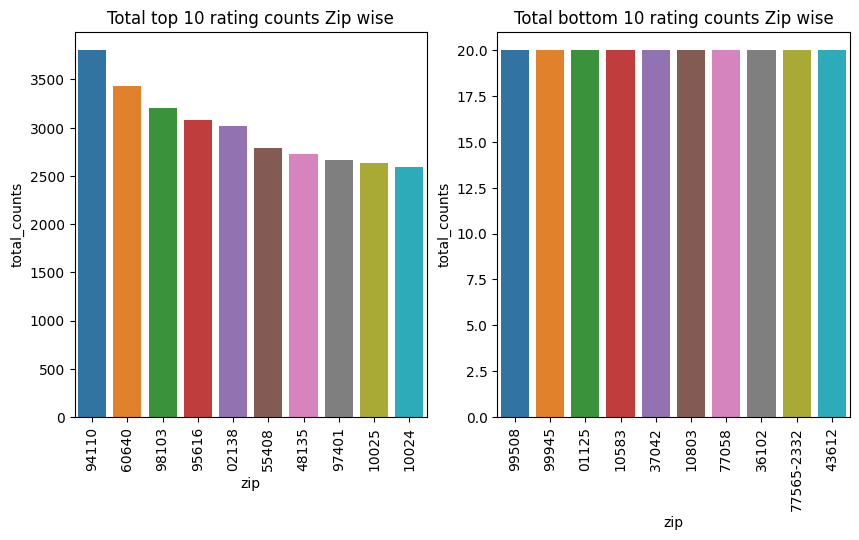

In [47]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(top_rating_count_zip_wise.head(10),x=top_rating_count_zip_wise['zip'].head(10),y=top_rating_count_zip_wise['total_counts'].head(10),hue='zip')
plt.xticks(rotation=90)
plt.title('Total top 10 rating counts Zip wise')
plt.subplot(1,2,2)
sns.barplot(bottom_rating_count_zip_wise.head(10),x=bottom_rating_count_zip_wise['zip'].head(10),y=bottom_rating_count_zip_wise['total_counts'].head(10),hue='zip')
plt.xticks(rotation=90)
plt.title('Total bottom 10 rating counts Zip wise')
plt.show()

##### Insight :

* zip 94110 area has highest rating count
* zip 99508,99945,etc have lowest rating count